# Multiple Instance Learning on MNIST Bags
### Mark Sterkel, David Rath

This notebook implements and compares three MIL aggregation strategies on a synthetic MNIST bag dataset. A *bag* is positive iff it contains at least one instance of the target digit (9). Models are trained with only bag-level labels and evaluated on held-out test bags.

| **Aggregator** | **Test AUC** |
|----------------|--------------|
| Mean pooling   |    0.8976    |
| Max pooling    |    0.9705    |
| ABMIL (gated attention) | **0.9774** |

The notebook is structured as follows:
1. MNIST Bags Dataset
2. Model
3. Training
4. Analysis & Visualisation

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import MNIST
from torchvision import transforms
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
from sklearn.manifold import TSNE
import torch
import torch.nn as nn

In [2]:
# connect to the google drive
# from google.colab import drive
# drive.mount('/content/drive')

In [3]:
# the path to the google drive
# this one works for me, you might have a different one (david)
# PROJECT_ROOT = '/content/drive/MyDrive/Uni/NN/'
PROJECT_ROOT = '.'

DATA_DIR = f'{PROJECT_ROOT}/data'
CKPT_DIR  = f'{PROJECT_ROOT}/checkpoints'

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

In [4]:
# verify MNIST is found in data directory
print(f"MNIST found: {os.path.exists(f'{DATA_DIR}/MNIST')}")

MNIST found: True


In [5]:
# seed everything
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

Using device: cuda


## MNIST Bags Dataset

In [6]:
class MnistBags(Dataset):
    """MNIST with synthetic MIL bag construction.

    A bag is positive (label=1) iff it contains at least one instance of
    `target_number`.  Per-instance labels are returned as a third element so
    that attention weights can be sanity-checked against ground truth.

    Args:
        root:             Path passed to torchvision.datasets.MNIST.
        train:            Use the MNIST training split (60k) or test split (10k).
        target_number:    Digit class that makes a bag positive.
        mean_bag_length:  Mean number of instances per bag.
        var_bag_length:   Std-dev of the bag-length distribution.
        num_bags:         Number of bags to generate.
        seed:             RNG seed for reproducibility.
        transform:        Optional transform applied to each instance image.
                          Defaults to ToTensor + MNIST normalisation.
        download:         Download MNIST if not present at `root`.

    Returns (from __getitem__):
        bag             FloatTensor (N, 1, 28, 28)
        bag_label       int             (0 or 1)
        instance_labels BoolTensor (N,) (True where digit == target_number)
    """

    # MNIST normalisation stats
    # taken from https://github.com/pytorch/examples/blob/acc295dc7b90714f1bf47f06004fc19a7fe235c4/mnist/main.py#L118
    _MEAN = 0.1307
    _STD  = 0.3081

    def __init__(
        self,
        root: str,
        train: bool = True,
        target_number: int = 9,
        mean_bag_length: int = 10,
        var_bag_length: int = 2,
        num_bags: int = 250,
        seed: int = 1,
        transform=None,
        download: bool = False,
    ):
        super().__init__()
        self.target_number  = target_number
        self.mean_bag_length = mean_bag_length
        self.var_bag_length  = var_bag_length
        self.num_bags        = num_bags

        if transform is None:
            transform = transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize((self._MEAN,), (self._STD,)),
            ])

        mnist = MNIST(root=root, train=train, transform=transform, download=download)
        loader = DataLoader(mnist, batch_size=len(mnist), shuffle=False)
        all_imgs, all_labels = next(iter(loader))   # load full split into memory once

        self._bags, self._bag_labels, self._instance_labels = (
            self._build_bags(all_imgs, all_labels, seed)
        )

    def _build_bags(self, imgs, labels, seed):
        rng = np.random.default_rng(seed)
        n   = imgs.shape[0]

        bags, bag_labels, inst_labels = [], [], []
        for _ in range(self.num_bags):
            length = max(1, int(rng.normal(self.mean_bag_length, self.var_bag_length)))
            idx    = rng.integers(0, n, size=length)

            bag_imgs  = imgs[idx]                          # (length, 1, 28, 28)
            inst_lbl  = labels[idx] == self.target_number  # BoolTensor (length,)
            bag_lbl   = int(inst_lbl.any())

            bags.append(bag_imgs)
            inst_labels.append(inst_lbl)
            bag_labels.append(bag_lbl)

        return bags, bag_labels, inst_labels

    def __len__(self) -> int:
        return self.num_bags

    def __getitem__(self, index: int):
        return (
            self._bags[index],           # FloatTensor (N, 1, 28, 28)
            self._bag_labels[index],     # int
            self._instance_labels[index] # BoolTensor (N,)
        )

Bag index   : 76
Bag size    : 7 instances
Bag label   : 1  (positive)
Target (9)  : 2 / 7 instances


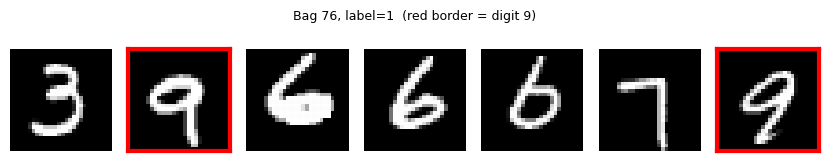

In [7]:
# instantiate a small dataset just for the demo
_demo_ds = MnistBags(root=DATA_DIR, train=True, target_number=9,
                     mean_bag_length=10, var_bag_length=2, num_bags=100, seed=42)

# always pick a positive bag so the red border is visible
_pos_idx = [i for i, (_, lbl, _) in enumerate(_demo_ds) if lbl == 1]
_idx     = int(np.random.default_rng().choice(_pos_idx))
bag, bag_label, inst_labels = _demo_ds[_idx]

print(f"Bag index   : {_idx}")
print(f"Bag size    : {bag.shape[0]} instances")
print(f"Bag label   : {bag_label}  ({'positive' if bag_label else 'negative'})")
print(f"Target (9)  : {inst_labels.sum().item()} / {len(inst_labels)} instances")

n = bag.shape[0]
fig, axes = plt.subplots(1, n, figsize=(n * 1.2, 1.6))
if n == 1:
    axes = [axes]
for ax, img, is_target in zip(axes, bag, inst_labels):
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        if is_target:
            spine.set_edgecolor("red")
            spine.set_linewidth(3)
        else:
            spine.set_visible(False)
plt.suptitle(f"Bag {_idx}, label={bag_label}  (red border = digit 9)", fontsize=9)
plt.tight_layout()
plt.show()

## Model

In [8]:
class MnistEncoder(nn.Module):
    """Small CNN encoder for 28x28 greyscale images.

    Architecture from the reference ABMIL implementation (Ilse et al. 2018):
      Conv(1->20, k=5) -> ReLU -> MaxPool(2)
      Conv(20->50, k=5) -> ReLU -> MaxPool(2)
      Linear(800->500) -> ReLU

    Input:  (N, 1, 28, 28)
    Output: (N, 500)
    """

    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 20, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2),
            nn.Conv2d(20, 50, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2),
        )
        self.fc = nn.Sequential(
            nn.Linear(50 * 4 * 4, 500),
            nn.ReLU(),
        )

    def forward(self, x):           # (N, 1, 28, 28)
        x = self.conv(x)            # (N, 50, 4, 4)
        x = x.flatten(start_dim=1)  # (N, 800)
        return self.fc(x)           # (N, 500)


class MeanPoolAggregator(nn.Module):
    """Element-wise mean over instance features."""

    def forward(self, h):                         # (N, L)
        return h.mean(dim=0, keepdim=True), None  # (1, L), None


class MaxPoolAggregator(nn.Module):
    """Element-wise max over instance features."""

    def forward(self, h):                                  # (N, L)
        return h.max(dim=0, keepdim=True).values, None     # (1, L), None


class AttentionAggregator(nn.Module):
    """Gated attention aggregator (Ilse et al., ICML 2018).

    Attention score per instance:
        a_i = softmax( w^T ( tanh(V h_i) o s(U h_i) ) )

    Bag representation:
        z = sum_i a_i h_i

    Args:
        L: input feature dimension (must match encoder output)
        D: internal attention dimension
    """

    def __init__(self, L: int = 500, D: int = 128):
        super().__init__()
        self.V = nn.Linear(L, D)
        self.U = nn.Linear(L, D)
        self.w = nn.Linear(D, 1)

    def forward(self, h):                                           # (N, L)
        a = self.w(torch.tanh(self.V(h)) * torch.sigmoid(self.U(h)))  # (N, 1)
        a = torch.softmax(a, dim=0)                                 # (N, 1)
        z = (a * h).sum(dim=0, keepdim=True)                        # (1, L)
        return z, a.squeeze(1)                                      # (1, L), (N,)


class MILModel(nn.Module):
    """Encoder + aggregator + binary bag classifier.

    Always returns (logit, attention_weights), where attention_weights is None
    for non-adaptive aggregators (mean / max pooling).

    Args:
        encoder:    Instance-level feature extractor.
        aggregator: One of MeanPoolAggregator, MaxPoolAggregator, AttentionAggregator.
        feat_dim:   Dimensionality of encoder output (default 500).
    """

    def __init__(self, encoder: nn.Module, aggregator: nn.Module, feat_dim: int = 500):
        super().__init__()
        self.encoder    = encoder
        self.aggregator = aggregator
        self.classifier = nn.Linear(feat_dim, 1)

    def forward(self, bag):                     # (N, 1, 28, 28)
        h          = self.encoder(bag)          # (N, feat_dim)
        z, weights = self.aggregator(h)         # (1, feat_dim), (N,) or None
        logit      = self.classifier(z).squeeze()  # scalar
        return logit, weights

In [9]:
# output shape check for all three aggregators
_bag = torch.randn(7, 1, 28, 28)

for name, agg in [("mean", MeanPoolAggregator()),
                  ("max",  MaxPoolAggregator()),
                  ("attn", AttentionAggregator())]:
    model  = MILModel(MnistEncoder(), agg)
    logit, weights = model(_bag)
    w_shape = tuple(weights.shape) if weights is not None else None
    print(f"{name:4s}  logit={tuple(logit.shape)}  weights={w_shape}")

mean  logit=()  weights=None
max   logit=()  weights=None
attn  logit=()  weights=(7,)


## Training

In [10]:
TARGET_NUMBER  = 9
MEAN_BAG_LEN   = 10
VAR_BAG_LEN    = 2
NUM_BAGS_TRAIN = 200
NUM_BAGS_VAL   = 50
NUM_BAGS_TEST  = 50

EPOCHS                  = 200
LR                      = 1e-4
WEIGHT_DECAY            = 1e-5
EARLY_STOPPING_PATIENCE = 10

# train and val draw from the MNIST train split (60k images) with different bag seeds
train_ds = MnistBags(root=DATA_DIR, train=True,  target_number=TARGET_NUMBER,
                     mean_bag_length=MEAN_BAG_LEN, var_bag_length=VAR_BAG_LEN,
                     num_bags=NUM_BAGS_TRAIN, seed=1)
val_ds   = MnistBags(root=DATA_DIR, train=True,  target_number=TARGET_NUMBER,
                     mean_bag_length=MEAN_BAG_LEN, var_bag_length=VAR_BAG_LEN,
                     num_bags=NUM_BAGS_VAL,   seed=2)
test_ds  = MnistBags(root=DATA_DIR, train=False, target_number=TARGET_NUMBER,
                     mean_bag_length=MEAN_BAG_LEN, var_bag_length=VAR_BAG_LEN,
                     num_bags=NUM_BAGS_TEST,  seed=3)

# batch_size=1: each iteration processes one bag of variable length
train_loader = DataLoader(train_ds, batch_size=1, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=1, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=1, shuffle=False)

for split, ds in [("Train", train_ds), ("Val  ", val_ds), ("Test ", test_ds)]:
    pos = sum(ds._bag_labels)
    print(f"{split}: {len(ds)} bags  ({pos} positive, {len(ds)-pos} negative)")

Train: 200 bags  (133 positive, 67 negative)
Val  : 50 bags  (35 positive, 15 negative)
Test : 50 bags  (32 positive, 18 negative)


### Dataset Statistics

Three views of the generated bags:
- **Bag size distribution**: follows the truncated normal (mean=10, std=2) used in construction.
- **Positive / negative ratio**: bags are independently sampled; the positive rate varies slightly across splits.
- **Target digit count per positive bag**: most positive bags contain exactly one digit 9, so the model must pick out a single relevant instance from roughly ten.

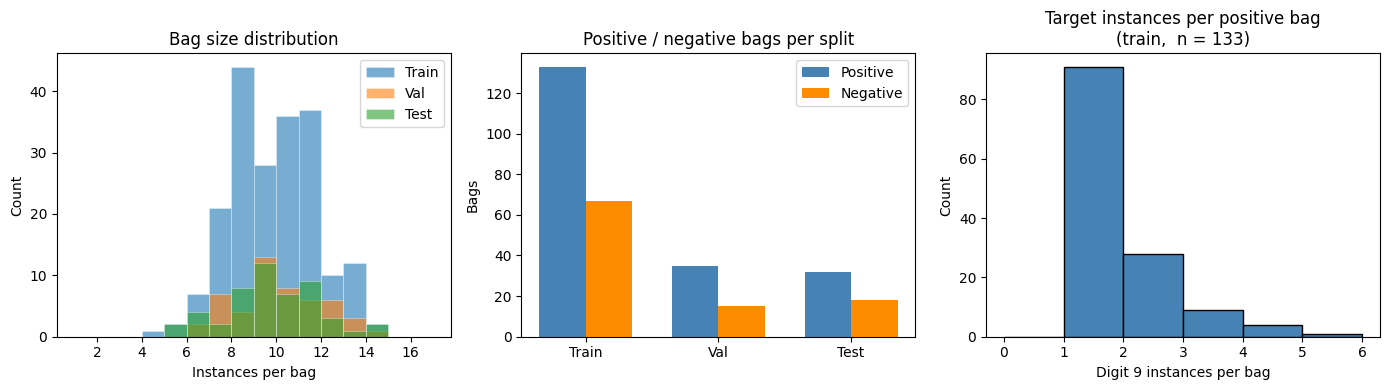

Bag length: mean=9.4  std=1.9  min=4  max=14
Train: 133/200 positive  (66%)
Val  : 35/50 positive  (70%)
Test : 32/50 positive  (64%)


In [11]:
splits = [("Train", train_ds), ("Val", val_ds), ("Test", test_ds)]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
for split_name, ds in splits:
    sizes = [bag.shape[0] for bag, _, _ in ds]
    ax.hist(sizes, bins=range(1, 18), alpha=0.6, label=split_name,
            edgecolor='white', linewidth=0.4)
ax.set_xlabel("Instances per bag")
ax.set_ylabel("Count")
ax.set_title("Bag size distribution")
ax.legend()

ax = axes[1]
x = np.arange(3)
pos_counts = [sum(ds._bag_labels) for _, ds in splits]
neg_counts  = [len(ds) - p for (_, ds), p in zip(splits, pos_counts)]
w = 0.35
ax.bar(x - w/2, pos_counts, w, label="Positive", color="steelblue")
ax.bar(x + w/2, neg_counts, w, label="Negative", color="darkorange")
ax.set_xticks(x)
ax.set_xticklabels([s for s, _ in splits])
ax.set_ylabel("Bags")
ax.set_title("Positive / negative bags per split")
ax.legend()

ax = axes[2]
target_counts = [inst_labels.sum().item() for _, lbl, inst_labels in train_ds if lbl == 1]
ax.hist(target_counts, bins=range(0, max(target_counts) + 2),
        edgecolor='black', color='steelblue')
ax.set_xlabel(f"Digit {TARGET_NUMBER} instances per bag")
ax.set_ylabel("Count")
ax.set_title(f"Target instances per positive bag\n(train,  n = {len(target_counts)})")

plt.tight_layout()
plt.show()

sizes_train = [bag.shape[0] for bag, _, _ in train_ds]
print(f"Bag length: mean={np.mean(sizes_train):.1f}  std={np.std(sizes_train):.1f}  "
      f"min={min(sizes_train)}  max={max(sizes_train)}")
for name, ds in splits:
    n_pos = sum(ds._bag_labels)
    print(f"{name:5s}: {n_pos}/{len(ds)} positive  ({100*n_pos/len(ds):.0f}%)")

In [12]:
# adapted from https://stackoverflow.com/a/73704579
class EarlyStopper:
    def __init__(self, patience=1, min_delta=0):
        self.patience  = patience
        self.min_delta = min_delta
        self.counter   = 0
        self.best      = float('inf')

    def step(self, val_loss):
        if val_loss < (self.best - self.min_delta):
            self.best    = val_loss
            self.counter = 0
            return False          # keep training
        self.counter += 1
        return self.counter >= self.patience  # True => stop


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for bag, label, _ in loader:
        bag   = bag.squeeze(0).to(device)
        label = label.float().squeeze().to(device)
        optimizer.zero_grad()
        logit, _ = model(bag)
        loss = criterion(logit, label)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def compute_val_loss(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for bag, label, _ in loader:
            bag   = bag.squeeze(0).to(device)
            label = label.float().squeeze().to(device)
            logit, _ = model(bag)
            total_loss += criterion(logit, label).item()
    return total_loss / len(loader)


def evaluate(model, loader, device):
    """Returns AUC on the given loader."""
    model.eval()
    probs, labels = [], []
    with torch.no_grad():
        for bag, label, _ in loader:
            bag = bag.squeeze(0).to(device)
            logit, _ = model(bag)
            probs.append(torch.sigmoid(logit).item())
            labels.append(label.item())
    return roc_auc_score(labels, probs)


def plot_confusion_matrix(model, loader, device, name):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for bag, label, _ in loader:
            bag = bag.squeeze(0).to(device)
            logit, _ = model(bag)
            preds.append((torch.sigmoid(logit) > 0.5).int().item())
            labels.append(label.item())
    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(3, 3))
    ax.imshow(cm, cmap='Blues')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=14,
                    color='white' if cm[i, j] > cm.max() / 2 else 'black')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Neg', 'Pos'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['Neg', 'Pos'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'{name} confusion matrix')
    plt.tight_layout()
    plt.show()


mean


mean:   0%|          | 0/200 [00:00<?, ?it/s]

  Early stopping at epoch 28


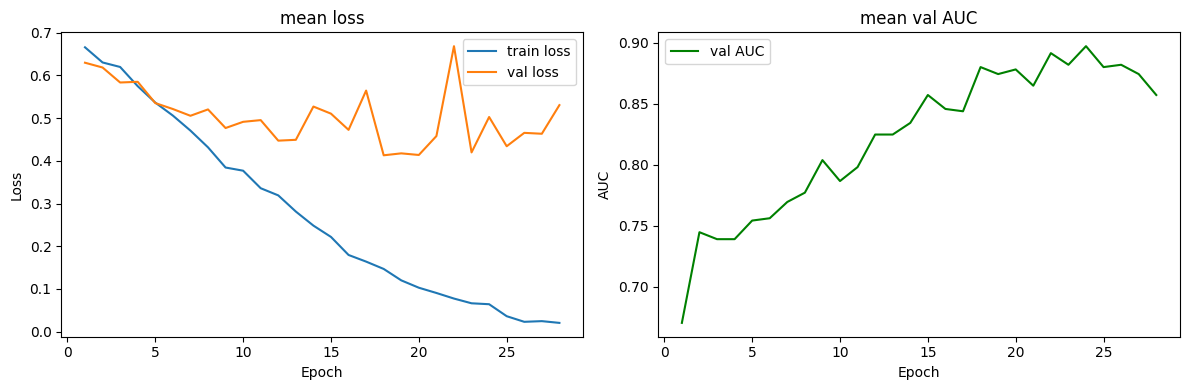


max


max:   0%|          | 0/200 [00:00<?, ?it/s]

  Early stopping at epoch 22


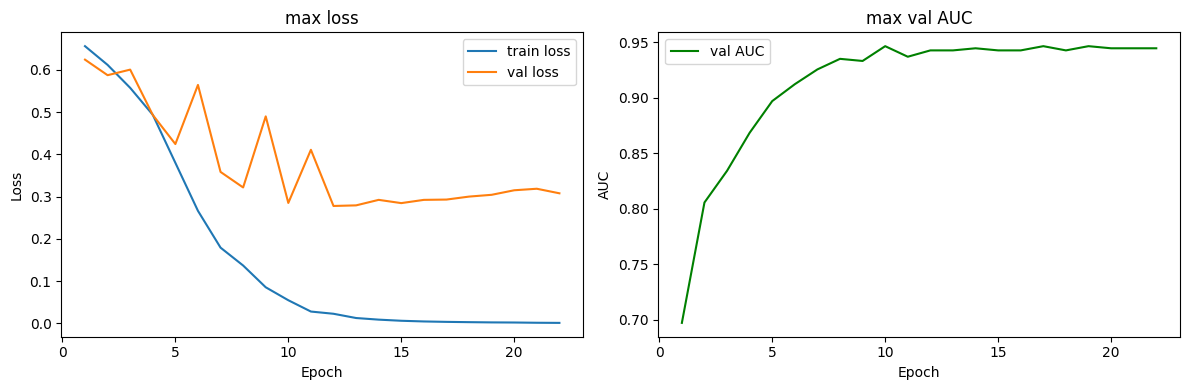


attn


attn:   0%|          | 0/200 [00:00<?, ?it/s]

  Early stopping at epoch 16


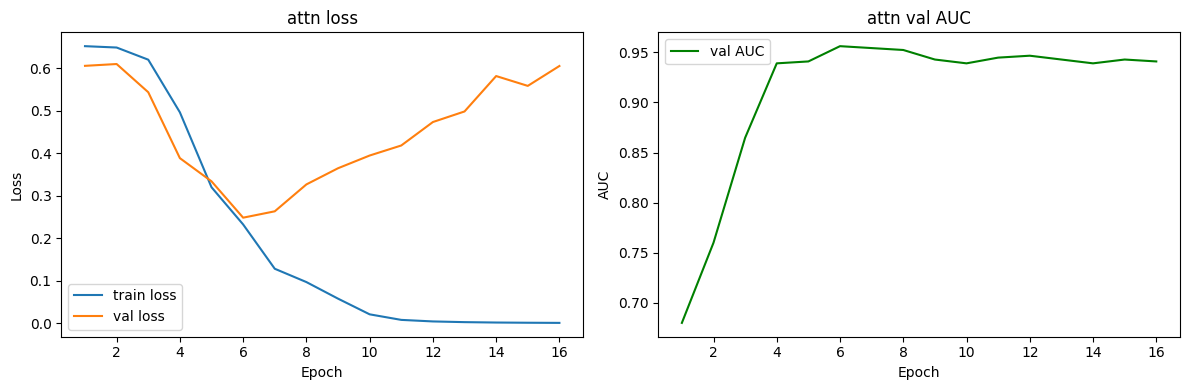


Summary (test set)
  mean  AUC=0.9010


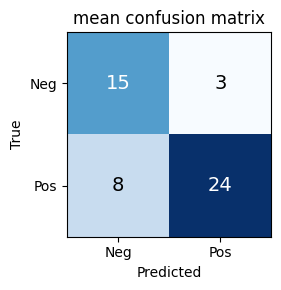

  max   AUC=0.9583


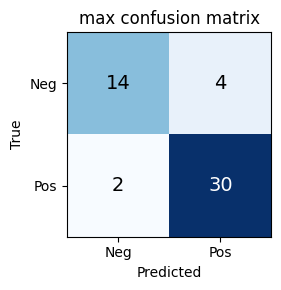

  attn  AUC=0.9705


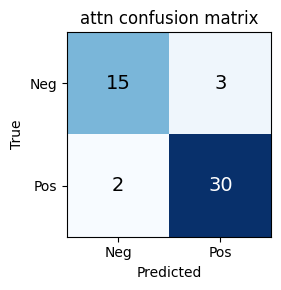

In [13]:
criterion = nn.BCEWithLogitsLoss()

configs = {
    "mean": MeanPoolAggregator(),
    "max":  MaxPoolAggregator(),
    "attn": AttentionAggregator(),
}

trained_models = {}

for name, agg in configs.items():
    print(f"\n{name}")
    model     = MILModel(MnistEncoder(), agg).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    stopper   = EarlyStopper(patience=EARLY_STOPPING_PATIENCE, min_delta=1e-3)

    train_losses, val_losses, val_aucs = [], [], []
    best_state = None

    for epoch in tqdm(range(1, EPOCHS + 1), desc=name, leave=True):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
        val_loss   = compute_val_loss(model, val_loader, criterion, DEVICE)
        val_auc    = evaluate(model, val_loader, DEVICE)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_aucs.append(val_auc)

        if val_loss <= stopper.best:
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if stopper.step(val_loss):
            print(f"  Early stopping at epoch {epoch}")
            break

    model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})

    epochs_ran = range(1, len(train_losses) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(epochs_ran, train_losses, label='train loss')
    ax1.plot(epochs_ran, val_losses,   label='val loss')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.set_title(f'{name} loss'); ax1.legend()
    ax2.plot(epochs_ran, val_aucs, color='green', label='val AUC')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('AUC')
    ax2.set_title(f'{name} val AUC'); ax2.legend()
    plt.tight_layout(); plt.show()

    torch.save(model.state_dict(), f"{CKPT_DIR}/mnist_{name}.pt")
    trained_models[name] = model

print("\nSummary (test set)")
for name, model in trained_models.items():
    test_auc = evaluate(model, test_loader, DEVICE)
    print(f"  {name:4s}  AUC={test_auc:.4f}")
    plot_confusion_matrix(model, test_loader, DEVICE, name)

In [14]:
# load trained checkpoints to skip retraining after a kernel restart
trained_models = {}
for name, agg in [("mean", MeanPoolAggregator()),
                  ("max",  MaxPoolAggregator()),
                  ("attn", AttentionAggregator())]:
    model = MILModel(MnistEncoder(), agg).to(DEVICE)
    model.load_state_dict(torch.load(f"{CKPT_DIR}/mnist_{name}.pt", weights_only=True))
    model.eval()
    trained_models[name] = model
    print(f"Loaded  {name}")

Loaded  mean
Loaded  max
Loaded  attn


In [15]:
# re-run after a kernel restart to restore analysis state without retraining

attn_model = trained_models["attn"]
attn_model.eval()

_MEAN_T = torch.tensor([0.1307])
_STD_T  = torch.tensor([0.3081])

def denorm(t):
    return (t * _STD_T + _MEAN_T).clamp(0, 1)

pos_indices = [i for i, (_, lbl, _) in enumerate(test_ds) if lbl == 1]
chosen = np.random.default_rng(SEED).choice(
    pos_indices, size=min(4, len(pos_indices)), replace=False
)

## Analysis & Visualisation

The following cells examine the trained ABMIL model qualitatively. The core question is whether the learned attention weights are semantically meaningful, i.e. whether high-weight instances actually are the target digit (9).

### ROC Curves

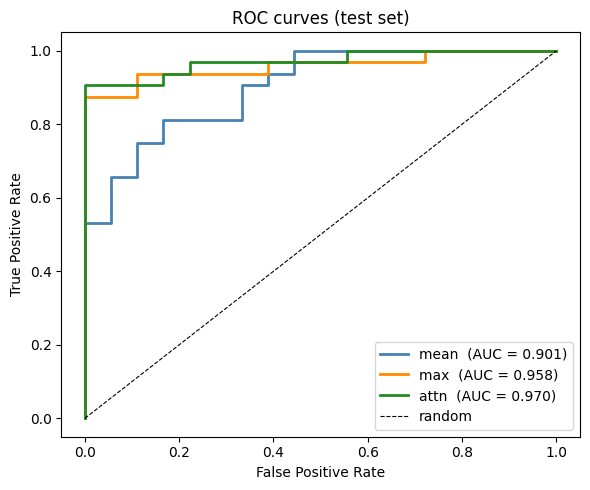

In [16]:
fig, ax = plt.subplots(figsize=(6, 5))
colors = {"mean": "steelblue", "max": "darkorange", "attn": "forestgreen"}

for name, model in trained_models.items():
    model.eval()
    probs, labels = [], []
    with torch.no_grad():
        for bag, label, _ in test_loader:
            bag = bag.squeeze(0).to(DEVICE)
            logit, _ = model(bag)
            probs.append(torch.sigmoid(logit).item())
            labels.append(label.item())
    fpr, tpr, _ = roc_curve(labels, probs)
    auc = roc_auc_score(labels, probs)
    ax.plot(fpr, tpr, label=f"{name}  (AUC = {auc:.3f})", color=colors[name], linewidth=2)

ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curves (test set)")
ax.legend()
plt.tight_layout()
plt.show()

### Instance-Level AUC

Since per-instance ground-truth labels are available, we can measure how well attention weights track positive instances, independent of bag-level accuracy. Each instance's attention weight is used as a proxy score; AUC is computed against the true instance label (is digit 9?). A high instance-level AUC means the model is attending to the right instances, not just classifying bags correctly.

In [17]:
inst_labels_all, inst_attn_all = [], []

attn_model.eval()
with torch.no_grad():
    for bag, _, inst_labels in test_ds:
        h = attn_model.encoder(bag.to(DEVICE))
        _, attn_w = attn_model.aggregator(h)
        inst_labels_all.append(inst_labels.numpy())
        inst_attn_all.append(attn_w.cpu().numpy())

inst_labels_flat = np.concatenate(inst_labels_all).astype(int)
inst_attn_flat   = np.concatenate(inst_attn_all)

inst_auc = roc_auc_score(inst_labels_flat, inst_attn_flat)
n_pos = inst_labels_flat.sum()
n_neg = len(inst_labels_flat) - n_pos
print(f"Instance-level AUC (attention as proxy score): {inst_auc:.4f}")
print(f"  {n_pos} positive instances,  {n_neg} negative  ({len(inst_labels_flat)} total)")

Instance-level AUC (attention as proxy score): 0.9171
  44 positive instances,  422 negative  (466 total)


### Attention Visualisation

Each row is one positive test bag. Instances are sorted left-to-right by decreasing attention weight. The border colour encodes the weight (green = high, red = low). Titles above each image are shown in **red** when the instance is the target digit (9). For a well-trained model, red titles should cluster on the left.

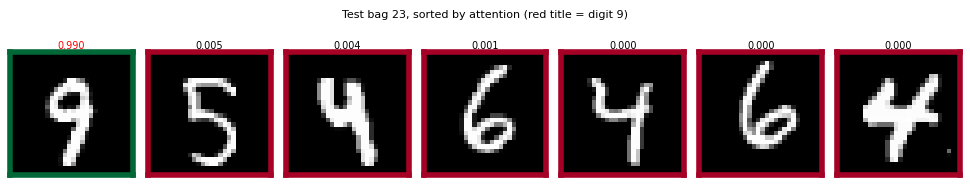

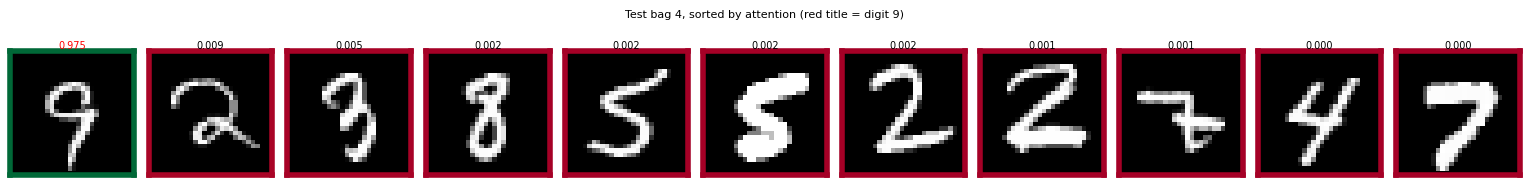

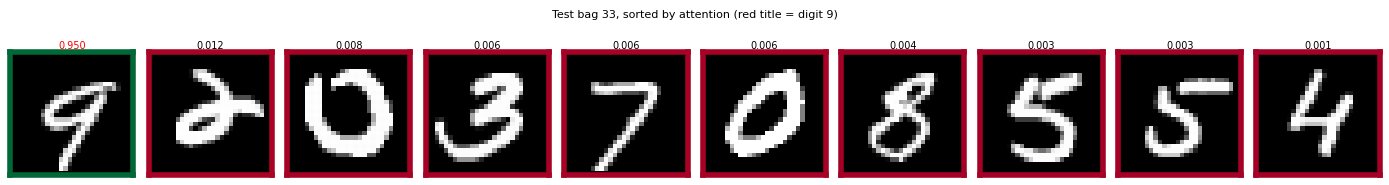

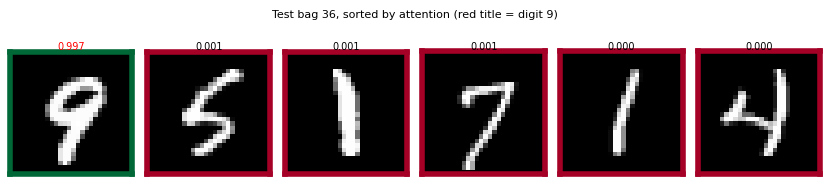

In [18]:
cmap = plt.cm.RdYlGn

for idx in chosen:
    bag, _, inst_labels = test_ds[idx]

    with torch.no_grad():
        h = attn_model.encoder(bag.to(DEVICE))
        _, attn = attn_model.aggregator(h)

    attn = attn.cpu().numpy()
    order       = np.argsort(attn)[::-1].copy()
    attn_sorted = attn[order]
    imgs_sorted = bag[order]
    is9_sorted  = inst_labels.numpy()[order]
    attn_norm   = (attn_sorted - attn_sorted.min()) / (attn_sorted.ptp() + 1e-8)

    n = len(order)
    fig, axes = plt.subplots(1, n, figsize=(n * 1.4, 1.9))
    if n == 1:
        axes = [axes]

    for i, (ax, img, is9) in enumerate(zip(axes, imgs_sorted, is9_sorted)):
        ax.imshow(denorm(img).squeeze(), cmap="gray", vmin=0, vmax=1)
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_edgecolor(cmap(attn_norm[i]))
            spine.set_linewidth(4)
        ax.set_title(f"{attn_sorted[i]:.3f}", fontsize=7,
                     color="red" if is9 else "black", pad=2)

    plt.suptitle(f"Test bag {idx}, sorted by attention (red title = digit 9)", fontsize=8)
    plt.tight_layout()
    plt.show()

### Top-Attended Instance per Positive Bag

For every positive test bag, we take the single instance with the highest attention weight and display it. If ABMIL has learned a meaningful signal, the majority should be digit 9 (green border = correct, red = wrong).

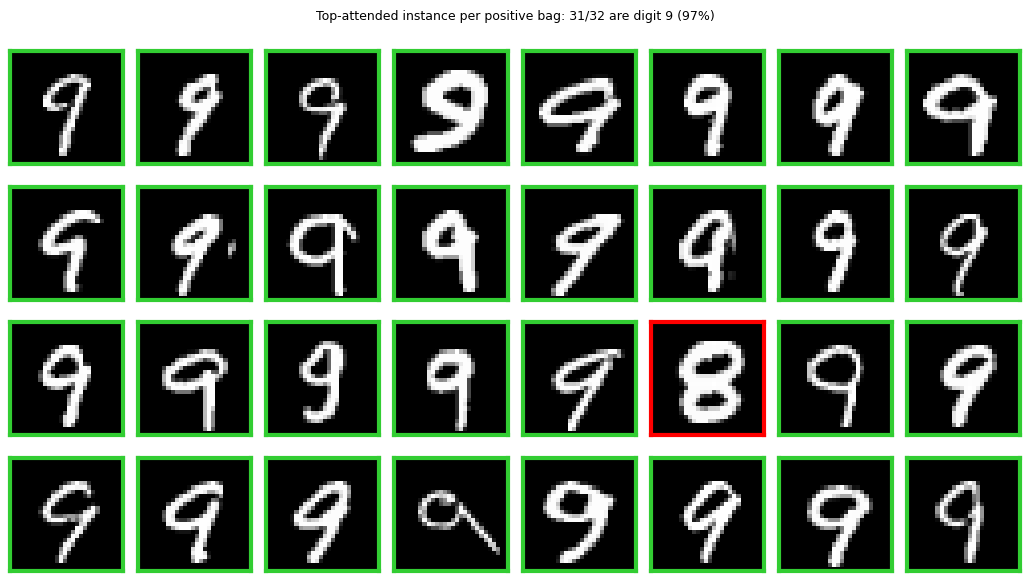

In [19]:
top_imgs, top_correct = [], []

attn_model.eval()
with torch.no_grad():
    for bag, label, inst_labels in test_ds:
        if label != 1:
            continue
        h = attn_model.encoder(bag.to(DEVICE))
        _, attn = attn_model.aggregator(h)
        best = attn.argmax().item()
        top_imgs.append(denorm(bag[best]))
        top_correct.append(bool(inst_labels[best]))

n      = len(top_imgs)
cols   = 8
rows   = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.3, rows * 1.5))
axes = np.array(axes).flatten()

for ax, img, correct in zip(axes, top_imgs, top_correct):
    ax.imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1)
    ax.set_xticks([])
    ax.set_yticks([])
    color = "limegreen" if correct else "red"
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)

for ax in axes[n:]:
    ax.axis("off")

n_correct = sum(top_correct)
plt.suptitle(
    f"Top-attended instance per positive bag: {n_correct}/{n} are digit 9 ({100*n_correct/n:.0f}%)",
    fontsize=9
)
plt.tight_layout()
plt.show()

### t-SNE of Encoder Features

We run all test-set instances through the CNN encoder, reduce the 500-dim features to 2D with t-SNE, and plot them twice: once coloured by whether the instance is digit 9, and once coloured by the attention weight ABMIL assigned to it. Good alignment between the two plots means the model is attending to instances that are genuinely distinctive in feature space.

Running t-SNE on 466 instances...


c:\Users\User\miniconda3\envs\project\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


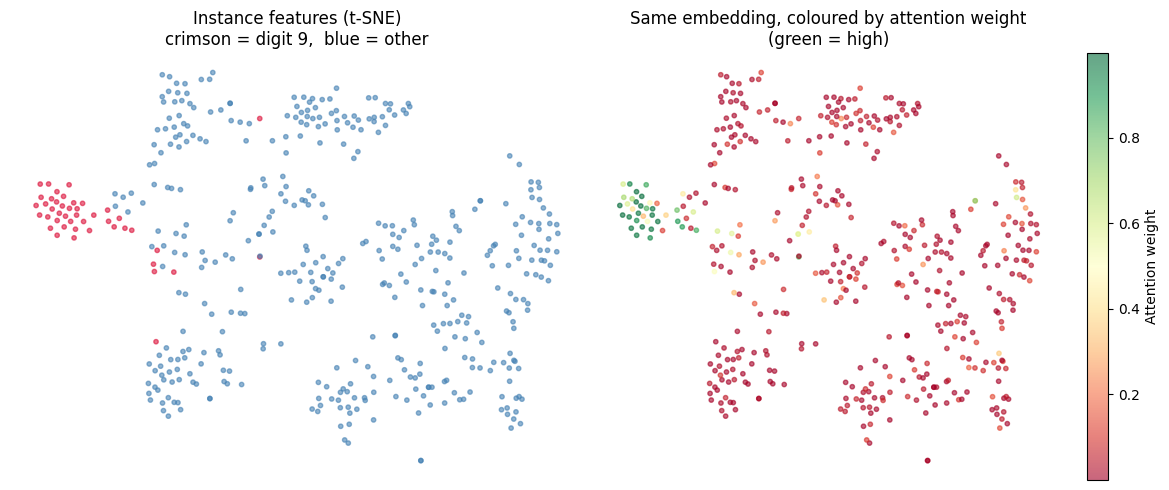

In [20]:
all_feats, all_is9, all_attn = [], [], []

attn_model.eval()
with torch.no_grad():
    for bag, _, inst_labels in test_ds:
        h = attn_model.encoder(bag.to(DEVICE))
        _, attn = attn_model.aggregator(h)
        all_feats.append(h.cpu())
        all_is9.append(inst_labels)
        all_attn.append(attn.cpu())

feats = torch.cat(all_feats).numpy()       # (total_instances, 500)
is9   = torch.cat(all_is9).numpy()         # (total_instances,) bool
attn  = torch.cat(all_attn).numpy()        # (total_instances,) float

print(f"Running t-SNE on {len(feats)} instances...")
coords = TSNE(n_components=2, random_state=SEED, perplexity=30).fit_transform(feats)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# left: is digit 9?
colors_cls = np.where(is9, "crimson", "steelblue")
ax1.scatter(coords[:, 0], coords[:, 1], c=colors_cls, s=10, alpha=0.6)
ax1.set_title("Instance features (t-SNE)\ncrimson = digit 9,  blue = other")
ax1.axis("off")

# right: attention weight
sc = ax2.scatter(coords[:, 0], coords[:, 1], c=attn, cmap="RdYlGn", s=10, alpha=0.6)
plt.colorbar(sc, ax=ax2, label="Attention weight")
ax2.set_title("Same embedding, coloured by attention weight\n(green = high)")
ax2.axis("off")

plt.tight_layout()
plt.show()

### Filter Activation Analysis

For each filter we find the global maximum activation across all test instances and crop the corresponding receptive field window from the input image. This shows the actual input pattern that most excited each filter, at native receptive field scale.

**Conv1** (20 filters): receptive field = 5x5 input pixels.  
**Conv2** (50 filters): receptive field = 14x14 input pixels; captures combinations of conv1-level features.

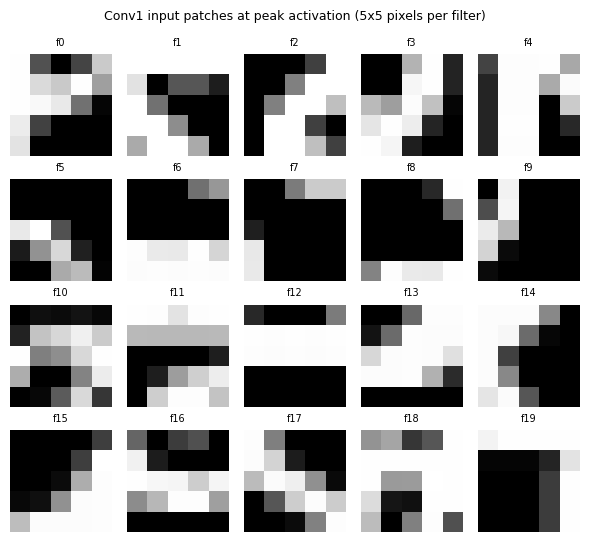

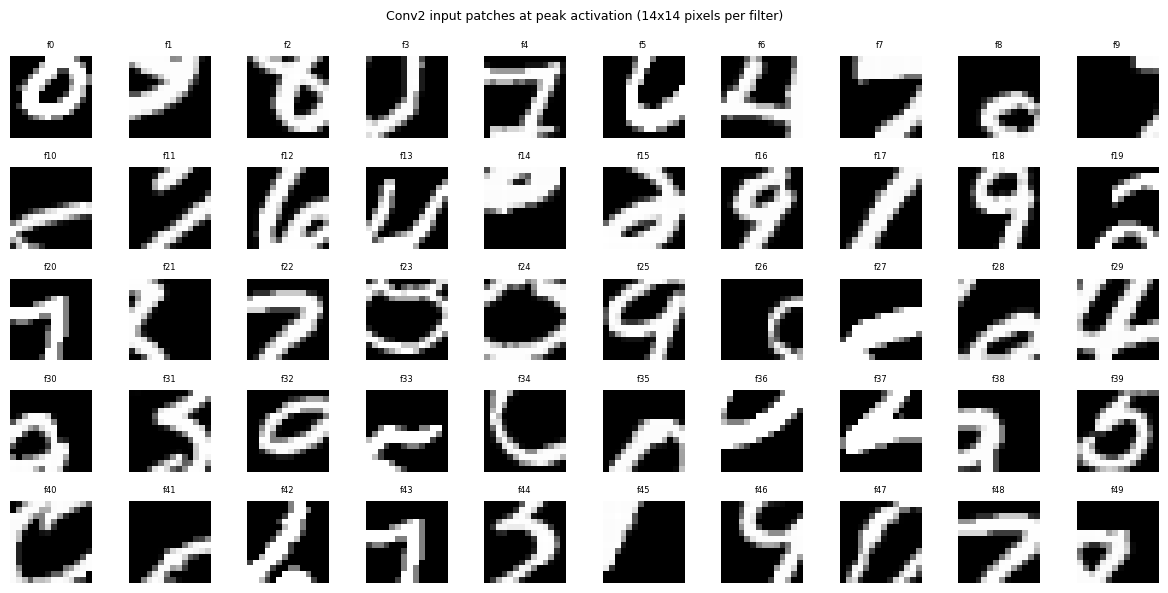

In [21]:
all_imgs_list, all_act1_list, all_act2_list = [], [], []

attn_model.eval()
with torch.no_grad():
    for bag, _, _ in test_ds:
        x  = bag.to(DEVICE)
        a1 = torch.relu(attn_model.encoder.conv[0](x))        # (N, 20, 24, 24)
        xp = attn_model.encoder.conv[2](a1)                    # (N, 20, 12, 12)
        a2 = torch.relu(attn_model.encoder.conv[3](xp))       # (N, 50,  8,  8)
        all_imgs_list.append(bag)
        all_act1_list.append(a1.cpu())
        all_act2_list.append(a2.cpu())

imgs_all = torch.cat(all_imgs_list)   # (M, 1, 28, 28)
act1_all = torch.cat(all_act1_list)   # (M, 20, 24, 24)
act2_all = torch.cat(all_act2_list)   # (M, 50,  8,  8)

# conv1 output position (h, w) maps to input pixels [h:h+5, w:w+5]
patches1 = []
for f in range(20):
    act_f = act1_all[:, f]
    flat  = act_f.reshape(-1).argmax().item()
    M_, H_, W_ = act_f.shape
    img_i = flat // (H_ * W_)
    sp    = flat %  (H_ * W_)
    h, w  = sp // W_, sp % W_
    patches1.append(denorm(imgs_all[img_i])[:, h:h+5, w:w+5].squeeze().numpy())

fig, axes = plt.subplots(4, 5, figsize=(6, 5.5))
for ax, patch, f in zip(axes.flat, patches1, range(20)):
    ax.imshow(patch, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
    ax.set_title(f"f{f}", fontsize=7)
    ax.axis('off')
plt.suptitle("Conv1 input patches at peak activation (5x5 pixels per filter)", fontsize=9)
plt.tight_layout()
plt.show()

# conv2 output (h, w) maps to input rows [2h:2h+14], cols [2w:2w+14]
# (2x stride from MaxPool1; conv2 k=5 spans 5 MaxPool1-input positions, each 2 conv1-output
#  pixels wide, each covering 5 input pixels -> 2+4+8=14)
patches2 = []
for f in range(50):
    act_f = act2_all[:, f]
    flat  = act_f.reshape(-1).argmax().item()
    M_, H_, W_ = act_f.shape
    img_i = flat // (H_ * W_)
    sp    = flat %  (H_ * W_)
    h, w  = sp // W_, sp % W_
    r0, c0 = 2 * h, 2 * w
    patches2.append(denorm(imgs_all[img_i])[:, r0:r0+14, c0:c0+14].squeeze().numpy())

fig, axes = plt.subplots(5, 10, figsize=(12, 6))
for ax, patch, f in zip(axes.flat, patches2, range(50)):
    ax.imshow(patch, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
    ax.set_title(f"f{f}", fontsize=6)
    ax.axis('off')
plt.suptitle("Conv2 input patches at peak activation (14x14 pixels per filter)", fontsize=9)
plt.tight_layout()
plt.show()

#### Conv1 Activation Maps for Specific Instances

Receptive field patches show what pattern maximally excites each filter across the dataset. The next visualisation shows *all 20 conv1 activation maps* for one digit 9 (target) and one non-target digit. Each map shows where in the image that filter fires. Comparing the two inputs reveals which filters are differentially activated by the target digit.

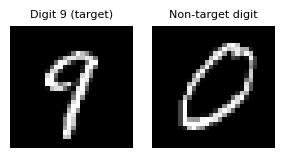

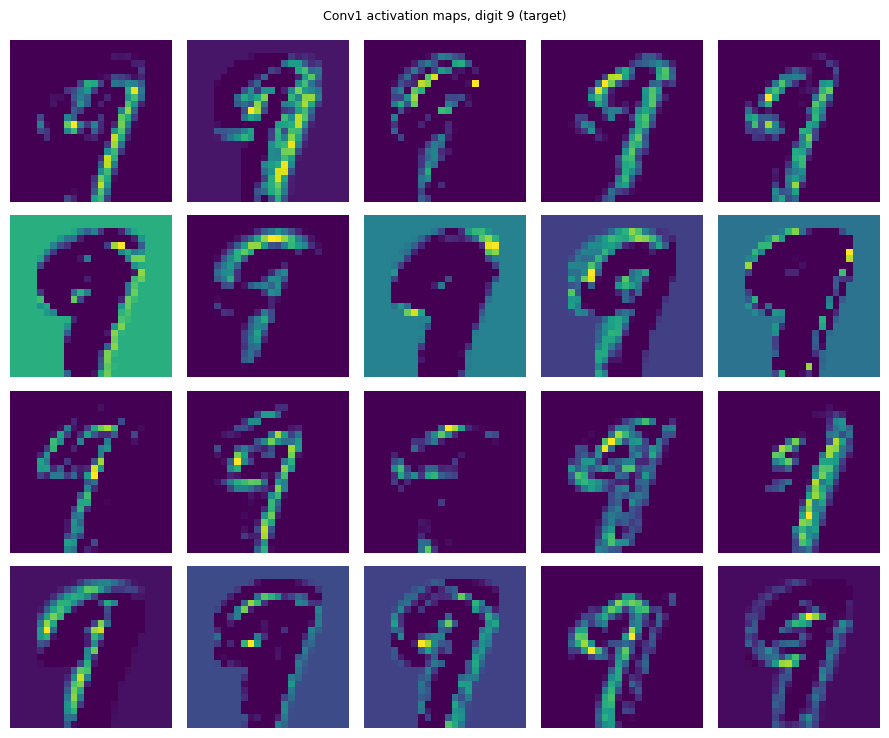

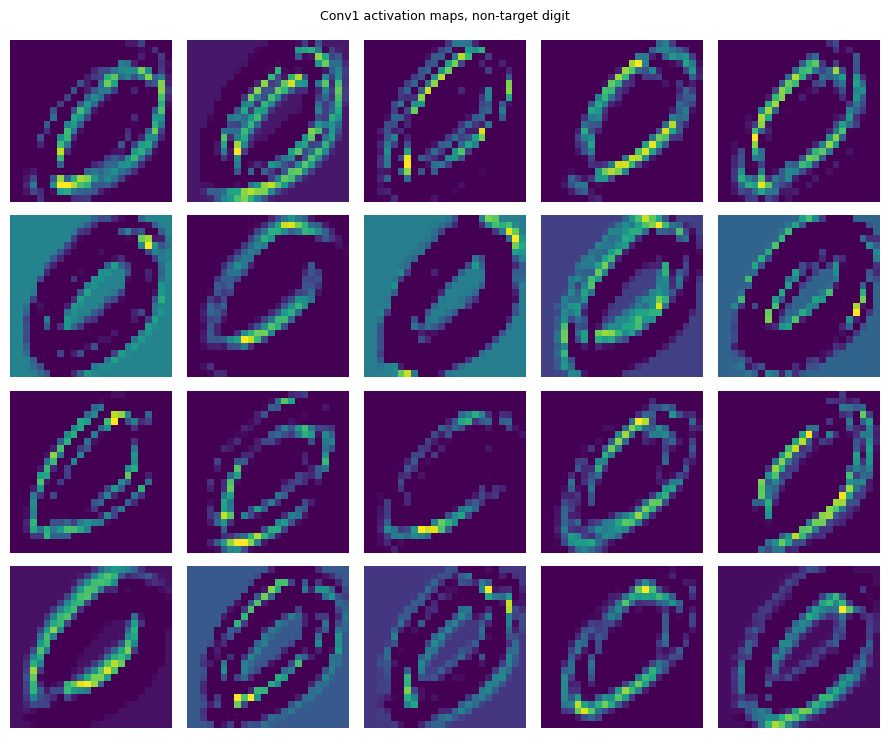

In [22]:
inst_9, inst_other = None, None
for bag, _, inst_labels in test_ds:
    for img, is9 in zip(bag, inst_labels):
        if is9.item() and inst_9 is None:
            inst_9 = img
        if not is9.item() and inst_other is None:
            inst_other = img
    if inst_9 is not None and inst_other is not None:
        break

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(3, 1.6))
ax1.imshow(denorm(inst_9).squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
ax1.set_title(f"Digit {TARGET_NUMBER} (target)", fontsize=8)
ax1.axis('off')
ax2.imshow(denorm(inst_other).squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
ax2.set_title("Non-target digit", fontsize=8)
ax2.axis('off')
plt.tight_layout()
plt.show()

def show_conv1_activations(instance, title):
    with torch.no_grad():
        x = instance.unsqueeze(0).to(DEVICE)
        maps = torch.relu(attn_model.encoder.conv[0](x))[0].cpu()  # (20, 24, 24)
    fig, axes = plt.subplots(4, 5, figsize=(9, 7.5))
    for ax, m in zip(axes.flat, maps):
        m_norm = (m - m.min()) / (m.max() - m.min() + 1e-8)
        ax.imshow(m_norm.numpy(), cmap='viridis', interpolation='nearest')
        ax.axis('off')
    plt.suptitle(title, fontsize=9)
    plt.tight_layout()
    plt.show()

show_conv1_activations(inst_9,    f"Conv1 activation maps, digit {TARGET_NUMBER} (target)")
show_conv1_activations(inst_other, "Conv1 activation maps, non-target digit")

### Grad-CAM

Gradient-weighted Class Activation Mapping (Selvaraju et al., 2017) traces which pixels in each instance drive the bag-level prediction. We hook the ReLU after the second convolutional layer (8x8 feature maps), weight each channel by the global average gradient of the bag logit, sum and ReLU, then upsample to 28x28.

**Colormap:** alpha is set to the cam value, so pixels with low activation are transparent (the gray image shows through) and high-activation pixels are opaque and warm-coloured. The background stays gray; only high-gradient regions show colour.

Each figure mirrors the attention visualisation above: instances sorted left-to-right by decreasing weight. Top row shows the original image; bottom row shows the Grad-CAM overlay. High-attention instances (green border, left columns) should have the heatmap concentrated on the digit strokes.

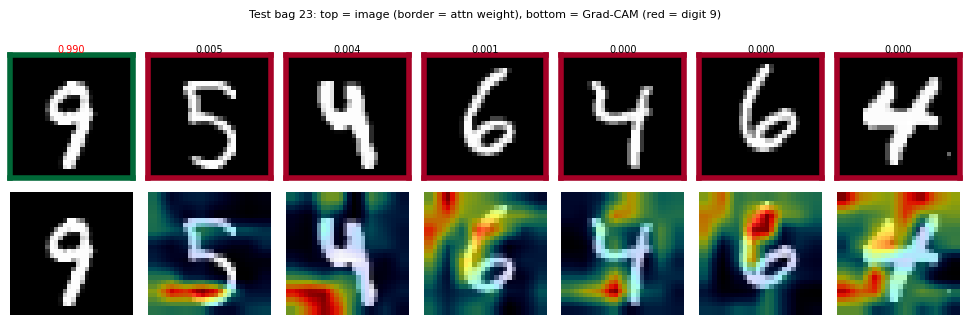

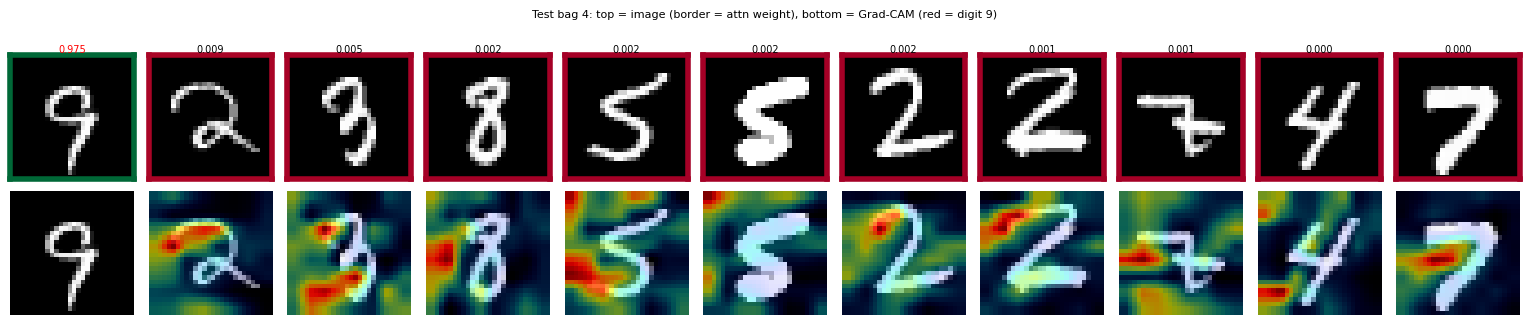

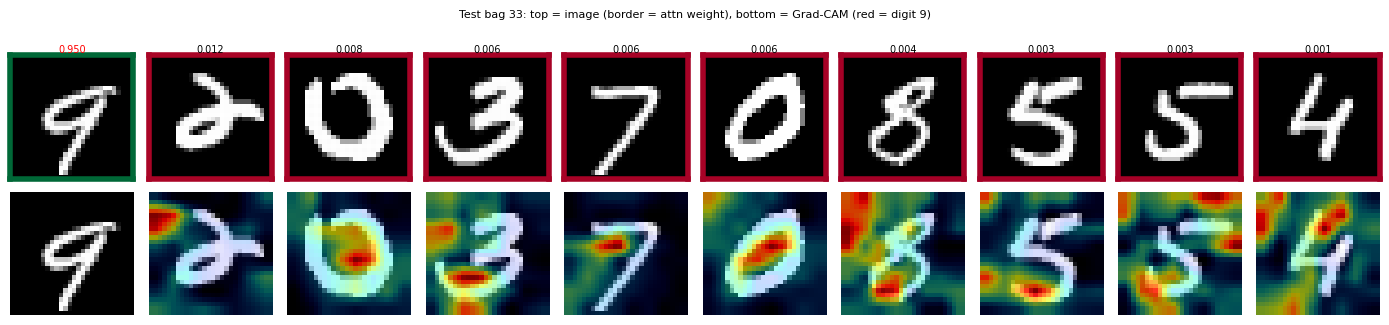

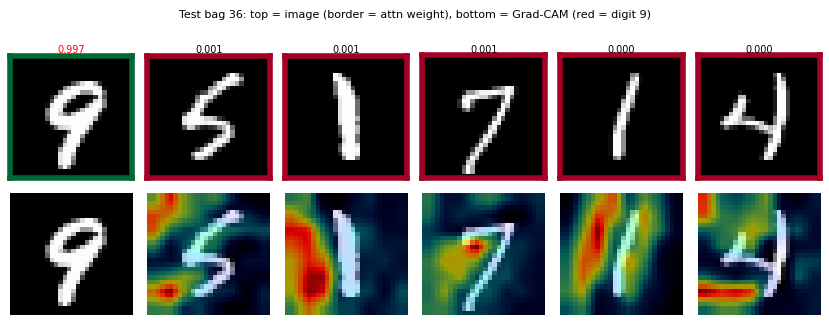

In [23]:
def compute_gradcam(model, bag, device):
    """Per-instance Grad-CAM from the bag-level logit.

    Hooks conv[4] (ReLU after conv2, 8x8 maps), weights channels by global-average
    gradient, sums and applies ReLU, then upsamples to 28x28.

    Returns FloatTensor (N, 28, 28) in [0, 1].
    """
    activations, gradients = {}, {}

    def fwd_hook(m, inp, out):
        activations['v'] = out

    def bwd_hook(m, grad_in, grad_out):
        gradients['v'] = grad_out[0]

    h1 = model.encoder.conv[4].register_forward_hook(fwd_hook)
    h2 = model.encoder.conv[4].register_full_backward_hook(bwd_hook)

    model.zero_grad()
    with torch.enable_grad():
        logit, _ = model(bag.to(device))
        logit.backward()

    h1.remove()
    h2.remove()

    acts    = activations['v']                               # (N, 50, 8, 8)
    grads   = gradients['v']                                 # (N, 50, 8, 8)
    weights = grads.mean(dim=(2, 3), keepdim=True)           # (N, 50, 1, 1)
    cam     = torch.relu((weights * acts).sum(dim=1))        # (N, 8, 8)

    cam = torch.nn.functional.interpolate(
        cam.unsqueeze(1), size=(28, 28), mode='bilinear', align_corners=False
    ).squeeze(1)                                             # (N, 28, 28)

    mn  = cam.flatten(1).min(dim=1).values.view(-1, 1, 1)
    mx  = cam.flatten(1).max(dim=1).values.view(-1, 1, 1)
    return ((cam - mn) / (mx - mn + 1e-8)).detach().cpu()


attn_model.eval()
cmap_border = plt.cm.RdYlGn

for idx in chosen:
    bag, _, inst_labels = test_ds[idx]

    with torch.no_grad():
        h = attn_model.encoder(bag.to(DEVICE))
        _, attn_w = attn_model.aggregator(h)
    attn_w = attn_w.cpu().numpy()

    cams = compute_gradcam(attn_model, bag, DEVICE)

    order       = np.argsort(attn_w)[::-1].copy()
    attn_sorted = attn_w[order]
    imgs_sorted = bag[order]
    is9_sorted  = inst_labels.numpy()[order]
    attn_norm   = (attn_sorted - attn_sorted.min()) / (attn_sorted.ptp() + 1e-8)
    cams_sorted = cams[order]

    n = len(order)
    fig, axes = plt.subplots(2, n, figsize=(n * 1.4, 3.4))
    if n == 1:
        axes = axes.reshape(2, 1)

    for i in range(n):
        img = denorm(imgs_sorted[i]).squeeze().numpy()
        cam = cams_sorted[i].numpy()
        is9 = is9_sorted[i]

        ax_top = axes[0, i]
        ax_top.imshow(img, cmap='gray', vmin=0, vmax=1)
        ax_top.set_xticks([])
        ax_top.set_yticks([])
        for spine in ax_top.spines.values():
            spine.set_edgecolor(cmap_border(attn_norm[i]))
            spine.set_linewidth(4)
        ax_top.set_title(f"{attn_sorted[i]:.3f}", fontsize=7,
                         color='red' if is9 else 'black', pad=2)

        cam_rgba         = plt.cm.jet(cam)
        cam_rgba[..., 3] = cam                 # alpha = cam magnitude
        ax_bot = axes[1, i]
        ax_bot.imshow(img, cmap='gray', vmin=0, vmax=1)
        ax_bot.imshow(cam_rgba)
        ax_bot.axis('off')

    plt.suptitle(
        f"Test bag {idx}: top = image (border = attn weight), bottom = Grad-CAM (red = digit 9)",
        fontsize=8
    )
    plt.tight_layout()
    plt.show()

### Misclassified Bags

We inspect every test bag the ABMIL model predicts incorrectly using the same attention-sorted layout.

- **False positives** (label=0, pred=1): the bag contains no digit 9, yet the model predicts positive. The highest-attended instance reveals what the model confused with the target.
- **False negatives** (label=1, pred=0): the bag contains at least one digit 9 (red title) but the model predicts negative. Low attention on the 9 means the model failed to localise the relevant instance; high attention on it despite negative prediction points to a classifier failure.

False positives: 3  (predicted positive, label negative)
False negatives: 2  (predicted negative, label positive)

False positives: top-attended instance is a non-9 that fooled the model


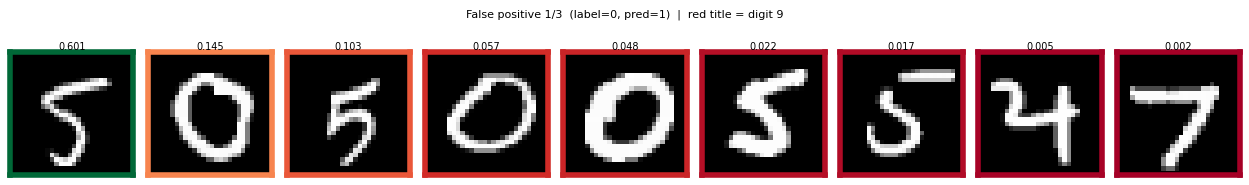

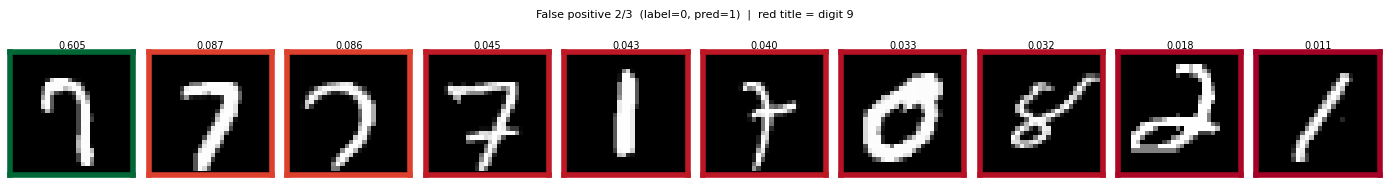

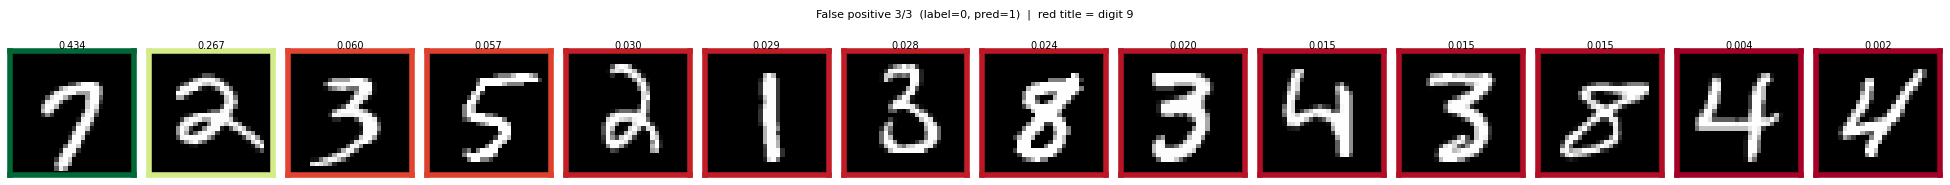


False negatives: model missed digit 9


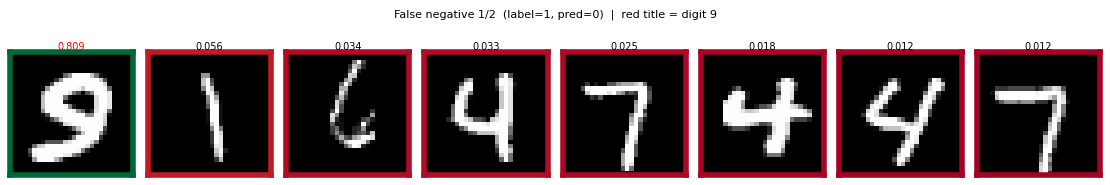

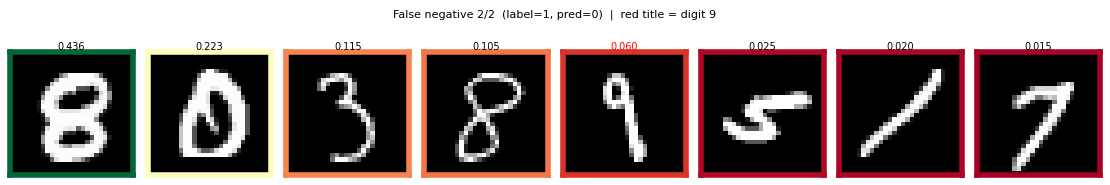

In [24]:
attn_model.eval()
fp_bags, fn_bags = [], []

with torch.no_grad():
    for bag, label, inst_labels in test_ds:
        logit, attn_w = attn_model(bag.to(DEVICE))
        pred = int(torch.sigmoid(logit) > 0.5)
        if pred == 1 and label == 0:
            fp_bags.append((bag, inst_labels, attn_w.cpu().numpy()))
        elif pred == 0 and label == 1:
            fn_bags.append((bag, inst_labels, attn_w.cpu().numpy()))

print(f"False positives: {len(fp_bags)}  (predicted positive, label negative)")
print(f"False negatives: {len(fn_bags)}  (predicted negative, label positive)")

def show_bag_with_attn(bag, inst_labels, attn_w, title):
    order       = np.argsort(attn_w)[::-1].copy()
    attn_sorted = attn_w[order]
    imgs_sorted = bag[order]
    is9_sorted  = inst_labels.numpy()[order]
    attn_norm   = (attn_sorted - attn_sorted.min()) / (attn_sorted.ptp() + 1e-8)
    n = len(order)
    fig, axes = plt.subplots(1, n, figsize=(n * 1.4, 1.9))
    if n == 1:
        axes = [axes]
    for i, (ax, img, is9) in enumerate(zip(axes, imgs_sorted, is9_sorted)):
        ax.imshow(denorm(img).squeeze(), cmap='gray', vmin=0, vmax=1)
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_edgecolor(plt.cm.RdYlGn(attn_norm[i]))
            spine.set_linewidth(4)
        ax.set_title(f"{attn_sorted[i]:.3f}", fontsize=7,
                     color='red' if is9 else 'black', pad=2)
    plt.suptitle(title, fontsize=8)
    plt.tight_layout()
    plt.show()

MAX_SHOW = 3

if fp_bags:
    print(f"\nFalse positives: top-attended instance is a non-{TARGET_NUMBER} that fooled the model")
    for i, (bag, inst_labels, attn_w) in enumerate(fp_bags[:MAX_SHOW]):
        show_bag_with_attn(bag, inst_labels, attn_w,
            f"False positive {i+1}/{len(fp_bags)}  (label=0, pred=1)  |  red title = digit {TARGET_NUMBER}")
else:
    print("No false positives on this test set.")

if fn_bags:
    print(f"\nFalse negatives: model missed digit {TARGET_NUMBER}")
    for i, (bag, inst_labels, attn_w) in enumerate(fn_bags[:MAX_SHOW]):
        show_bag_with_attn(bag, inst_labels, attn_w,
            f"False negative {i+1}/{len(fn_bags)}  (label=1, pred=0)  |  red title = digit {TARGET_NUMBER}")
else:
    print(f"No false negatives on this test set.")